In [1]:
import pandas as pd
import os

In [2]:
# Base path
base_path = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/CTCF_elimination/gamma_300.0_repeated"

In [4]:
# List to store dataframes
dfs = []

# Read dataframes for folds 0-7
for fold in range(8):
    file_path = os.path.join(base_path, f"fold{fold}_g300.0_genomic_windows_table_results_shuffle.tsv")
    
    print(f"Reading fold {fold}...")
    try:
        df = pd.read_csv(file_path, sep="\t")
        # Add a column to track which fold this data came from
        df['fold'] = fold
        dfs.append(df)
        print(f"  Loaded {len(df)} rows from fold {fold}")
    except FileNotFoundError:
        print(f"  Warning: File not found for fold {fold}")
    except Exception as e:
        print(f"  Error reading fold {fold}: {e}")

Reading fold 0...
  Loaded 46 rows from fold 0
Reading fold 1...
  Loaded 60 rows from fold 1
Reading fold 2...
  Loaded 58 rows from fold 2
Reading fold 3...
  Loaded 54 rows from fold 3
Reading fold 4...
  Loaded 56 rows from fold 4
Reading fold 5...
  Loaded 39 rows from fold 5
Reading fold 6...
  Loaded 52 rows from fold 6
Reading fold 7...
  Loaded 41 rows from fold 7


In [5]:
# Concatenate all dataframes
if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    print(f"\nCombined dataframe shape: {combined_df.shape}")
    print(f"Total rows: {len(combined_df)}")
    print(f"\nColumns: {list(combined_df.columns)}")
    
    # Save combined dataframe
    output_path = os.path.join(base_path, "all_folds_combined_results_shuffle.tsv")
    combined_df.to_csv(output_path, sep="\t", index=False)
    print(f"\nSaved combined results to: {output_path}")
    
    # Display first few rows
    print("\nFirst few rows:")
    print(combined_df.head())
    
    # Summary statistics
    print("\nSummary statistics:")
    print(combined_df.describe())
else:
    print("No dataframes were loaded!")


Combined dataframe shape: (406, 26)
Total rows: 406

Columns: ['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end', 'centered_flat_start', 'centered_flat_end', 'active_fraction', 'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init', 'URQ_shuffle', 'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation', 'positions']

Saved combined results to: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/CTCF_elimination/gamma_300.0_repeated/all_folds_combined_results_shuffle.tsv

First few rows:
   chrom  fold  PearsonR  centered_start  centered_end  centered_flat_start  \
0   chr1     0  0.861165        37799936      39110656                  192   
1  chr11     0  0.746112        65677312      66988032                  195   
2   chr3     0  0.670098        38524928      39835648                  144   
3   chr3     0  0.672787        532869

In [7]:
combined_df["URQ_diff"] = combined_df["URQ_result"] - combined_df["URQ_init"]

In [9]:
# selecting only sequences with no CTCF detected
combined_df = combined_df[combined_df["CTCFs_num"] == 0]

In [10]:
# selecting only sequences with a measurable contact depletion
combined_df = combined_df[combined_df['URQ_diff'] < 0.0]

In [11]:
len(combined_df)

195

In [12]:
combined_df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'last_accepted_step', 'SCD',
       'URQ_result', 'URQ_target', 'URQ_init', 'URQ_shuffle', 'num_edits',
       'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num',
       'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'URQ_diff'],
      dtype='object')

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


Saved boxplot to: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/CTCF_elimination/gamma_300.0_repeated/URQ_comparison_boxplot.png
Saved boxplot to: /project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/CTCF_elimination/gamma_300.0_repeated/URQ_comparison_boxplot.pdf


/tmp/SLURM_2609523/ipykernel_402119/3281892981.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(data=df_melted, x='Condition', y='URQ_value',
/tmp/SLURM_2609523/ipykernel_402119/3281892981.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Initial', 'Result', 'Shuffle'])


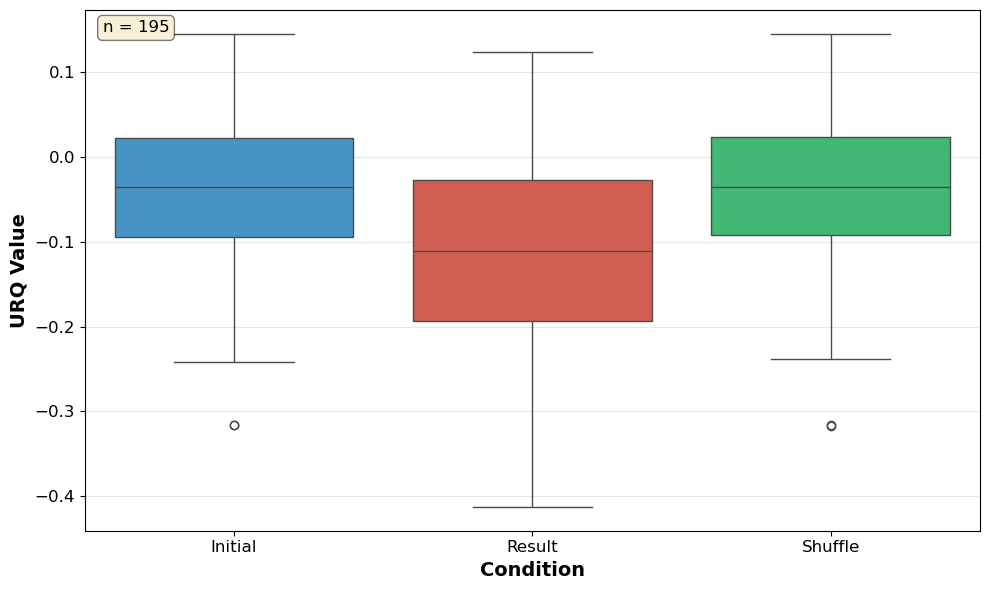

In [17]:
# Prepare data for boxplot by melting the dataframe
urq_columns = ['URQ_init', 'URQ_result', 'URQ_shuffle']
df_melted = combined_df[urq_columns].melt(var_name='Condition', value_name='URQ_value')

# Create boxplot
fig, ax = plt.subplots(figsize=(10, 6))

# Create the boxplot
bp = sns.boxplot(data=df_melted, x='Condition', y='URQ_value', 
                 palette=['#3498db', '#e74c3c', '#2ecc71'],
                 ax=ax)

# Customize the plot
ax.set_xlabel('Condition', fontsize=14, fontweight='bold')
ax.set_ylabel('URQ Value', fontsize=14, fontweight='bold')
# ax.set_title('Comparison of URQ Metrics Across All Folds', fontsize=16, fontweight='bold')
ax.tick_params(labelsize=12)

# Set x-tick labels to be more readable
ax.set_xticklabels(['Initial', 'Result', 'Shuffle'])

# Add grid for better readability
ax.yaxis.grid(True, alpha=0.3)

# Add sample size annotation
n_samples = len(combined_df)
ax.text(0.02, 0.98, f'n = {n_samples}', 
        transform=ax.transAxes, 
        fontsize=12, 
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Save the figure
output_path = os.path.join(base_path, "URQ_comparison_boxplot.png")
# plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\nSaved boxplot to: {output_path}")

# Also save as PDF
output_path_pdf = os.path.join(base_path, "URQ_comparison_boxplot.pdf")
# plt.savefig(output_path_pdf, bbox_inches='tight')
print(f"Saved boxplot to: {output_path_pdf}")

In [15]:
# Print summary statistics
print("\n" + "="*60)
print("Summary Statistics:")
print("="*60)
for col in urq_columns:
    print(f"\n{col}:")
    print(f"  Mean:   {combined_df[col].mean():.6f}")
    print(f"  Median: {combined_df[col].median():.6f}")
    print(f"  Std:    {combined_df[col].std():.6f}")
    print(f"  Min:    {combined_df[col].min():.6f}")
    print(f"  Max:    {combined_df[col].max():.6f}")

# Statistical comparison
print("\n" + "="*60)
print("Pairwise Differences:")
print("="*60)
print(f"\nURQ_result - URQ_init:")
print(f"  Mean:   {(combined_df['URQ_result'] - combined_df['URQ_init']).mean():.6f}")
print(f"  Median: {(combined_df['URQ_result'] - combined_df['URQ_init']).median():.6f}")

print(f"\nURQ_shuffle - URQ_init:")
print(f"  Mean:   {(combined_df['URQ_shuffle'] - combined_df['URQ_init']).mean():.6f}")
print(f"  Median: {(combined_df['URQ_shuffle'] - combined_df['URQ_init']).median():.6f}")

print(f"\nURQ_result - URQ_shuffle:")
print(f"  Mean:   {(combined_df['URQ_result'] - combined_df['URQ_shuffle']).mean():.6f}")
print(f"  Median: {(combined_df['URQ_result'] - combined_df['URQ_shuffle']).median():.6f}")

plt.show()


Summary Statistics:

URQ_init:
  Mean:   -0.044147
  Median: -0.035480
  Std:    0.089590
  Min:    -0.315599
  Max:    0.145214

URQ_result:
  Mean:   -0.112679
  Median: -0.111307
  Std:    0.111882
  Min:    -0.412685
  Max:    0.123720

URQ_shuffle:
  Mean:   -0.044008
  Median: -0.035971
  Std:    0.089448
  Min:    -0.316982
  Max:    0.145248

Pairwise Differences:

URQ_result - URQ_init:
  Mean:   -0.068532
  Median: -0.061046

URQ_shuffle - URQ_init:
  Mean:   0.000139
  Median: -0.000018

URQ_result - URQ_shuffle:
  Mean:   -0.068671
  Median: -0.061477
